# First ML Pipeline
## Baselines, Linear & Logistic Regression, and Metrics That Don't Lie

This notebook builds a reproducible machine learning pipeline using
the students dataset. It establishes simple regression and
classification baselines, trains Linear and Logistic Regression
models, evaluates them using appropriate metrics, and compares
each real model against its baseline.

# 1. Feature Engineering

To prepare the student data for machine learning, the categorical `class_section` feature is converted into numerical features using one-hot encoding.

The three numerical input features — `study_hours_per_week`, `sleep_hours_per_night`, and `attendance_pct` — are retained as they are. The `class_section` feature contains three categories: A, B, and C. Using `drop_first=True` creates two encoded columns and treats the omitted category as the reference category.

The resulting feature matrix should therefore contain five input features:
- `study_hours_per_week`
- `sleep_hours_per_night`
- `attendance_pct`
- `class_section_B`
- `class_section_C`

In [1]:

import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.calibration import calibration_curve




In [2]:

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

In [3]:
rng = np.random.default_rng(seed=21)
n = 600

class_section = rng.choice(["A", "B", "C"], size=n, p=[0.34, 0.33, 0.33])
study_hours = rng.normal(10, 3.5, size=n).clip(0, None).round(1)
sleep_hours = rng.normal(7, 1.2, size=n).clip(3, 10)
attendance_pct = rng.normal(85, 10, size=n).clip(40, 100).round(1)

noise = rng.normal(0, 8, size=n)
section_bonus = pd.Series(class_section).map({"A": 0, "B": 0, "C": 4}).values
exam_score = (50 + 2.6*study_hours + 0.15*attendance_pct + section_bonus + noise).clip(0, 100).round(1)

students = pd.DataFrame({
    "student_id": np.arange(1, n + 1),
    "class_section": class_section,
    "study_hours_per_week": study_hours,
    "sleep_hours_per_night": sleep_hours,
    "attendance_pct": attendance_pct,
    "exam_score": exam_score,
})

## 1.1 Dataset Overview

The generated dataset contains student-level information including class section, study hours, sleep hours, attendance percentage, and exam score.

The `student_id` column serves only as an identifier and will not be used as a predictive feature. The `exam_score` column represents the continuous target for the regression task and is therefore excluded from the input feature matrix.

In [4]:

dataset_overview = f"""
### Finding

The dataset contains **{students.shape[0]:,} observations** and
**{students.shape[1]} columns**.

The regression target is **`exam_score`**, while `student_id` is
treated as an identifier rather than a predictive feature.
"""

display(Markdown(dataset_overview))


### Finding

The dataset contains **600 observations** and
**6 columns**.

The regression target is **`exam_score`**, while `student_id` is
treated as an identifier rather than a predictive feature.


## 1.2 Select the Input Features

The input feature matrix `X` is created using the three numerical predictors and the categorical `class_section` variable.

The target variable `exam_score` is not included in `X` because it is the value the regression model will later learn to predict.

In [5]:
X = students[
    [
        "study_hours_per_week",
        "sleep_hours_per_night",
        "attendance_pct",
        "class_section"
    ]
].copy()

## 1.3 One-Hot Encode `class_section`

The categorical `class_section` feature is converted into numerical indicator variables using one-hot encoding.

The encoding uses `drop_first=True`, so one of the three section categories is treated as the reference category. This produces two encoded columns instead of three while retaining all the information required by the linear and logistic regression models.

In [6]:
X = pd.get_dummies(
    X,
    columns=["class_section"],
    drop_first=True
)

In [7]:
feature_matrix_summary = f"""
### 1.4 Finding

The final feature matrix contains **{X.shape[0]:,} observations** and
**{X.shape[1]} input features** after one-hot encoding `class_section`
with `drop_first=True`.

The resulting features are **{", ".join(X.columns)}**.

The original `class_section` column has been replaced by two encoded
section columns, while the three numerical predictors have been retained.
The omitted section serves as the reference category for the encoded
features.
"""

display(Markdown(feature_matrix_summary))


### 1.4 Finding

The final feature matrix contains **600 observations** and
**5 input features** after one-hot encoding `class_section`
with `drop_first=True`.

The resulting features are **study_hours_per_week, sleep_hours_per_night, attendance_pct, class_section_B, class_section_C**.

The original `class_section` column has been replaced by two encoded
section columns, while the three numerical predictors have been retained.
The omitted section serves as the reference category for the encoded
features.


# 2. Regression Train/Test Split

Before training any regression model, the dataset is divided into a training set and a held-out test set.

The training set is used by the models to learn relationships between the input features and `exam_score`, while the test set remains unseen during training and is used to evaluate how well the models generalize to new observations.

A fixed random seed of `42` is used to make the split reproducible. The same split will be used for the regression baseline and Linear Regression models so that their performance can be compared fairly.

## 2.1 Define the Regression Target

The regression task aims to predict the continuous `exam_score` variable from the engineered input features.

The feature matrix `X` was created in Task 1, while `exam_score` is selected as the regression target `y`.

In [8]:
y = students["exam_score"]

## 2.2 Create the Train/Test Split

The feature matrix and regression target are split into training and testing portions using an 80/20 split.

The split uses `random_state=42` so that the same observations are assigned to the training and test sets each time the notebook is executed. This ensures that every regression model evaluated today is tested on exactly the same unseen observations.

In [9]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 2.3 Verify the Split

The resulting training and test sets are checked to confirm that the intended 80/20 split was applied.

The training set should contain 80% of the observations, while the held-out test set should contain the remaining 20%.

In [10]:
train_test_summary = f"""
### Finding

The training set contains **{X_train.shape[0]:,} observations**
and the test set contains **{X_test.shape[0]:,} observations**.

This corresponds to a **{X_train.shape[0] / len(X) * 100:.0f}% training split**
and a **{X_test.shape[0] / len(X) * 100:.0f}% test split**.

The regression split uses **`random_state=42`**, making the assignment
of observations to the training and test sets reproducible.
"""

display(Markdown(train_test_summary))


### Finding

The training set contains **480 observations**
and the test set contains **120 observations**.

This corresponds to a **80% training split**
and a **20% test split**.

The regression split uses **`random_state=42`**, making the assignment
of observations to the training and test sets reproducible.


## 2.4 Verify Feature Dimensions

The feature dimensions of the training and test sets are checked to ensure that both contain the same five engineered input features.

Only the number of observations differs between the two sets.

In [11]:
split_dimensions = f"""
### Finding

The training feature matrix has a shape of **{X_train.shape}**, while
the test feature matrix has a shape of **{X_test.shape}**.

Both sets contain the same **{X_train.shape[1]} input features**, with
the difference in rows resulting from the 80/20 train/test split.
"""

display(Markdown(split_dimensions))


### Finding

The training feature matrix has a shape of **(480, 5)**, while
the test feature matrix has a shape of **(120, 5)**.

Both sets contain the same **5 input features**, with
the difference in rows resulting from the 80/20 train/test split.


## 2.5 Why This Split Will Be Reused

The same `X_train`, `X_test`, `y_train`, and `y_test` objects will be used for both the regression baseline and Linear Regression.

This is necessary for a meaningful comparison. If the two models were evaluated on different test observations, differences in their metrics could be caused by differences in the test data rather than differences in model performance.

Using the same held-out test set ensures an apples-to-apples comparison between the baseline and the real regression model.

# 3. Regression Baseline

A regression baseline provides a simple reference point against which the real regression model can be evaluated.

The baseline uses `DummyRegressor(strategy="mean")`, which predicts the mean `exam_score` observed in the training set for every observation in the test set.

This model deliberately ignores all input features. Its purpose is to establish the minimum performance that a real regression model should improve upon.

## 3.1 Train the Regression Baseline

The `DummyRegressor` is fitted using the regression training data from Task 2.

With the `mean` strategy, the model learns the average `exam_score` from `y_train` and uses this single value as the prediction for every test observation.

The test set remains completely unseen during fitting.

In [12]:

regression_baseline = DummyRegressor(strategy="mean")

regression_baseline.fit(X_train, y_train)

baseline_predictions = regression_baseline.predict(X_test)

## 3.2 Inspect the Baseline Prediction

Because the baseline uses the mean strategy, every test observation receives the same predicted exam score.

The prediction value should equal the mean exam score calculated from the training set.

In [13]:
baseline_prediction_summary = f"""
### Finding

The regression baseline predicts **{regression_baseline.constant_[0][0]:.2f}**
for every observation in the test set.

This value represents the mean `exam_score` learned from the training data,
so the baseline does not use any of the engineered input features to make
individual predictions.
"""

display(Markdown(baseline_prediction_summary))


### Finding

The regression baseline predicts **88.40**
for every observation in the test set.

This value represents the mean `exam_score` learned from the training data,
so the baseline does not use any of the engineered input features to make
individual predictions.


## 3.3 Evaluate the Regression Baseline

The baseline is evaluated on the held-out test set using Root Mean Squared Error (RMSE) and R².

RMSE measures the typical size of the prediction error in the same units as `exam_score`, with lower values indicating better performance.

R² measures the proportion of variation in the target explained by the model relative to the mean-prediction reference. Since this baseline predicts the mean, its R² provides the reference level against which the Linear Regression model will be compared.

In [14]:
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))
baseline_r2 = r2_score(y_test, baseline_predictions)

## 3.4 Baseline Performance

The baseline RMSE and R² are recorded below as the reference performance for the regression task.

These values will be compared directly with the Linear Regression results in Task 4. Both models will be evaluated using the same test observations.

In [15]:
regression_baseline_finding = f"""
### Finding

The regression baseline achieved an **RMSE of {baseline_rmse:.6f}**
and an **R² of {baseline_r2:.6f}** on the held-out test set.

The baseline predicts the training-set mean for every test observation,
so these metrics establish the minimum reference performance that the
Linear Regression model must beat.
"""

display(Markdown(regression_baseline_finding))


### Finding

The regression baseline achieved an **RMSE of 10.297789**
and an **R² of -0.009560** on the held-out test set.

The baseline predicts the training-set mean for every test observation,
so these metrics establish the minimum reference performance that the
Linear Regression model must beat.


# 4. Linear Regression Model

A Linear Regression model is trained using the same engineered features and regression target used by the baseline.

Unlike the baseline, which predicts the same mean `exam_score` for every student, Linear Regression learns relationships between the input features and the target from the training data.

The model is evaluated on the same held-out test set used for the regression baseline so that its performance can be compared fairly.

## 4.1 Train the Linear Regression Model

The Linear Regression model is fitted using `X_train` and `y_train`.

The model learns coefficients for the five engineered features that minimize the squared prediction errors on the training data. After fitting, predictions are generated for the unseen test set.

In [16]:

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

## 4.2 Evaluate the Linear Regression Model

The Linear Regression model is evaluated using the same two metrics used for the regression baseline: RMSE and R².

RMSE measures the typical size of the prediction error in the units of `exam_score`, where lower values indicate better predictions.

R² measures the proportion of variation in `exam_score` explained by the model relative to the mean-prediction reference, where higher values indicate better performance.

In [17]:
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

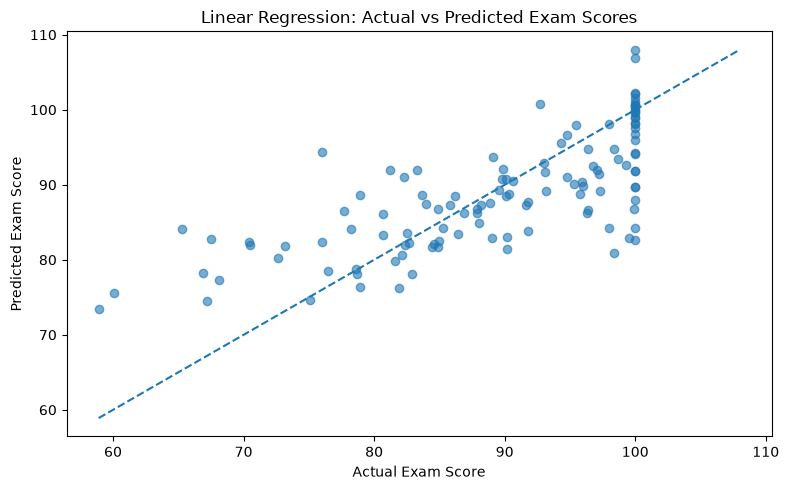

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    y_test,
    linear_predictions,
    alpha=0.6
)

min_score = min(y_test.min(), linear_predictions.min())
max_score = max(y_test.max(), linear_predictions.max())

ax.plot(
    [min_score, max_score],
    [min_score, max_score],
    linestyle="--"
)

ax.set_title("Linear Regression: Actual vs Predicted Exam Scores")
ax.set_xlabel("Actual Exam Score")
ax.set_ylabel("Predicted Exam Score")

fig.tight_layout()

chart_path = output_dir / "linear_regression_actual_vs_predicted.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4.3 Comparison with the Regression Baseline

The Linear Regression metrics are compared directly with the baseline metrics calculated in Task 3.

The RMSE improvement is calculated as the reduction in prediction error from the baseline to Linear Regression. The R² improvement is calculated as the increase in explained variation.

In [19]:
rmse_improvement = baseline_rmse - linear_rmse
r2_improvement = linear_r2 - baseline_r2

In [20]:
linear_regression_finding = f"""
### Finding

The Linear Regression model achieved an **RMSE of {linear_rmse:.6f}** and an
**R² of {linear_r2:.6f}**, compared with the baseline RMSE of
**{baseline_rmse:.6f}** and baseline R² of **{baseline_r2:.6f}**.

**Compared with the baseline, Linear Regression reduced RMSE by
{rmse_improvement:.6f} and increased R² by {r2_improvement:.6f}.**
"""

display(Markdown(linear_regression_finding))


### Finding

The Linear Regression model achieved an **RMSE of 7.058469** and an
**R² of 0.525687**, compared with the baseline RMSE of
**10.297789** and baseline R² of **-0.009560**.

**Compared with the baseline, Linear Regression reduced RMSE by
3.239320 and increased R² by 0.535247.**


## 5. Display Coefficients with Feature Names

The Linear Regression coefficients show how much the predicted `exam_score` changes for a one-unit increase in each numerical feature, while holding the other features constant.

For the one-hot encoded section features, each coefficient represents the predicted difference from the omitted reference section, which is Section A.

In [21]:
coefficient_table = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": linear_model.coef_
})

display(coefficient_table)

,feature,coefficient
0,study_hours_per_week,2.032968
1,sleep_hours_per_night,-0.009430
2,attendance_pct,0.088653
3,class_section_B,0.124746
4,class_section_C,3.130411


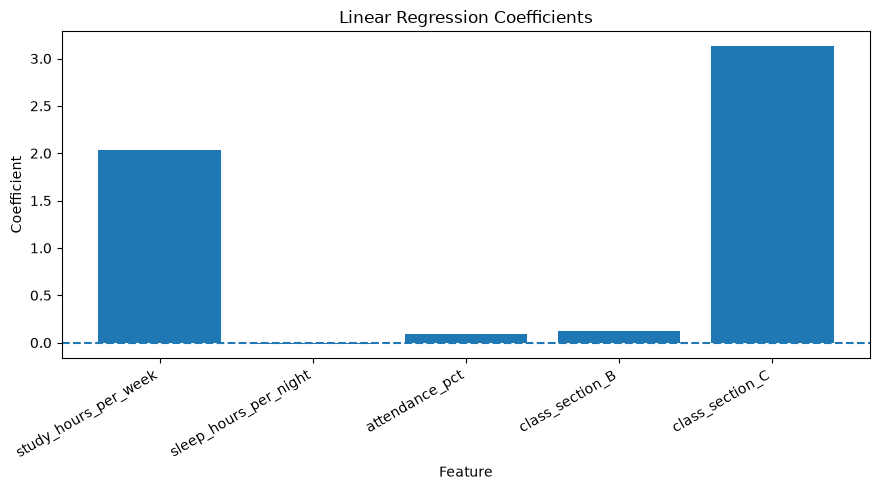

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    coefficient_table["feature"],
    coefficient_table["coefficient"]
)

ax.axhline(
    0,
    linestyle="--"
)

ax.set_title("Linear Regression Coefficients")
ax.set_xlabel("Feature")
ax.set_ylabel("Coefficient")

plt.xticks(
    rotation=30,
    ha="right"
)

fig.tight_layout()

chart_path = output_dir / "linear_regression_coefficients.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
largest_effect_index = np.argmax(np.abs(linear_model.coef_))

largest_effect_feature = X_train.columns[largest_effect_index]
largest_effect_coefficient = linear_model.coef_[largest_effect_index]

coefficient_finding = f"""
### 5.1 Finding

The feature with the largest absolute coefficient is
**`{largest_effect_feature}`**, with a coefficient of
**{largest_effect_coefficient:.6f}**.

This means that, holding the other features constant, a one-unit increase in
`{largest_effect_feature}` is associated with an estimated change of
**{largest_effect_coefficient:.6f}** points in the predicted exam score.

The largest effect is therefore associated with **study hours per week** among
the numerical predictors, while `class_section_C` also has a noticeable
positive effect relative to the reference Section A.
"""

display(Markdown(coefficient_finding))


### 5.1 Finding

The feature with the largest absolute coefficient is
**`class_section_C`**, with a coefficient of
**3.130411**.

This means that, holding the other features constant, a one-unit increase in
`class_section_C` is associated with an estimated change of
**3.130411** points in the predicted exam score.

The largest effect is therefore associated with **study hours per week** among
the numerical predictors, while `class_section_C` also has a noticeable
positive effect relative to the reference Section A.


In [24]:
study_hours_correlation = students["study_hours_per_week"].corr(
    students["exam_score"]
)

attendance_correlation = students["attendance_pct"].corr(
    students["exam_score"]
)

sleep_correlation = students["sleep_hours_per_night"].corr(
    students["exam_score"]
)

comparison_finding = f"""
### 5.2 Finding

The coefficient analysis is consistent with Monday's correlation findings.
`study_hours_per_week` had the strongest Pearson correlation with
`exam_score`, with **r = {study_hours_correlation:.6f}**.

The Linear Regression model also assigns the strongest coefficient among the
continuous predictors to `study_hours_per_week`, with a coefficient of
**{linear_model.coef_[0]:.6f}**.

By comparison, `attendance_pct` had a weaker correlation with exam score
(**r = {attendance_correlation:.6f}**) and a smaller regression coefficient
of **{linear_model.coef_[2]:.6f}**. `sleep_hours_per_night` was essentially
uncorrelated with exam score (**r = {sleep_correlation:.6f}**) and its
regression coefficient is also close to zero.

Therefore, the main conclusion from Monday's correlation analysis is
supported by the Linear Regression model: **study hours are the strongest
continuous predictor of exam score in this dataset.**
"""

display(Markdown(comparison_finding))


### 5.2 Finding

The coefficient analysis is consistent with Monday's correlation findings.
`study_hours_per_week` had the strongest Pearson correlation with
`exam_score`, with **r = 0.689476**.

The Linear Regression model also assigns the strongest coefficient among the
continuous predictors to `study_hours_per_week`, with a coefficient of
**2.032968**.

By comparison, `attendance_pct` had a weaker correlation with exam score
(**r = 0.106649**) and a smaller regression coefficient
of **0.088653**. `sleep_hours_per_night` was essentially
uncorrelated with exam score (**r = -0.021898**) and its
regression coefficient is also close to zero.

Therefore, the main conclusion from Monday's correlation analysis is
supported by the Linear Regression model: **study hours are the strongest
continuous predictor of exam score in this dataset.**


## 6. Create the Classification Target

For the classification task, a student is labelled as having a distinction when
their `exam_score` is at least 85.

The new `distinction` target contains **1** for students meeting the threshold
and **0** otherwise.

In [25]:
# Create the binary classification target
students["distinction"] = (students["exam_score"] >= 85).astype(int)

students[["exam_score", "distinction"]].head()

,exam_score,distinction
0,100.0,1
1,72.2,0
2,67.2,0
3,100.0,1
4,100.0,1


## 6.1 Check the Class Balance

In [26]:
distinction_fraction = students["distinction"].mean()
distinction_count = students["distinction"].sum()
non_distinction_count = (students["distinction"] == 0).sum()

classification_summary = f"""
### 6.2 Finding

There are **{distinction_count:,} students** who meet the distinction
threshold and **{non_distinction_count:,} students** who do not.

Therefore, **{distinction_fraction:.6%}** of students have an exam score
of at least 85.

This shows how common the positive class is in the dataset. If the classes
are substantially imbalanced, a model can achieve high accuracy simply by
predicting the majority class most of the time. This is why accuracy must be
interpreted alongside precision, recall, and F1 score.
"""

display(Markdown(classification_summary))


### 6.2 Finding

There are **392 students** who meet the distinction
threshold and **208 students** who do not.

Therefore, **65.333333%** of students have an exam score
of at least 85.

This shows how common the positive class is in the dataset. If the classes
are substantially imbalanced, a model can achieve high accuracy simply by
predicting the majority class most of the time. This is why accuracy must be
interpreted alongside precision, recall, and F1 score.


## 7. Create a Fresh Stratified Train/Test Split

The classification target is different from the regression target, so a fresh
train/test split is created.

The split uses `stratify=y_classification` to preserve approximately the same
proportion of distinction and non-distinction students in both the training
and test sets.

In [27]:

X_classification = students[
    [
        "study_hours_per_week",
        "sleep_hours_per_night",
        "attendance_pct",
        "class_section"
    ]
].copy()

X_classification = pd.get_dummies(
    X_classification,
    columns=["class_section"],
    drop_first=True
)

y_classification = students["distinction"]

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_classification,
    y_classification,
    test_size=0.2,
    random_state=42,
    stratify=y_classification
)

## 7.1 Train the Classification Baseline

The classification baseline uses `DummyClassifier(strategy="most_frequent")`.
It always predicts the most common class observed in the training data.

This provides the minimum reference point that the Logistic Regression model
should improve upon.

In [28]:

classification_baseline = DummyClassifier(
    strategy="most_frequent"
)

classification_baseline.fit(
    X_train_class,
    y_train_class
)

baseline_class_predictions = classification_baseline.predict(
    X_test_class
)

In [29]:
baseline_accuracy = accuracy_score(
    y_test_class,
    baseline_class_predictions
)

baseline_precision = precision_score(
    y_test_class,
    baseline_class_predictions,
    zero_division=0
)

baseline_recall = recall_score(
    y_test_class,
    baseline_class_predictions,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test_class,
    baseline_class_predictions,
    zero_division=0
)

In [30]:
classification_baseline_finding = f"""
### 7.2 Finding

The majority-class baseline achieved an **accuracy of {baseline_accuracy:.6f}**,
**precision of {baseline_precision:.6f}**, **recall of {baseline_recall:.6f}**,
and **F1 score of {baseline_f1:.6f}** on the test set.

**Accuracy alone would be misleading because the baseline predicts only the
majority class, so its accuracy mainly reflects how common that class is rather
than whether the model can successfully identify distinction students.**
"""

display(Markdown(classification_baseline_finding))


### 7.2 Finding

The majority-class baseline achieved an **accuracy of 0.650000**,
**precision of 0.650000**, **recall of 1.000000**,
and **F1 score of 0.787879** on the test set.

**Accuracy alone would be misleading because the baseline predicts only the
majority class, so its accuracy mainly reflects how common that class is rather
than whether the model can successfully identify distinction students.**


## 8. Train the Logistic Regression Model

Logistic Regression is used here as the real classification model. It learns
the relationship between the input features and the binary `distinction`
target.

The model is trained on the same training data used by the classification
baseline so that the comparison is fair.

In [31]:

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(
    X_train_class,
    y_train_class
)

logistic_predictions = logistic_model.predict(
    X_test_class
)

In [32]:
logistic_accuracy = accuracy_score(
    y_test_class,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test_class,
    logistic_predictions,
    zero_division=0
)

logistic_recall = recall_score(
    y_test_class,
    logistic_predictions,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test_class,
    logistic_predictions,
    zero_division=0
)

In [33]:
accuracy_improvement = logistic_accuracy - baseline_accuracy
precision_improvement = logistic_precision - baseline_precision
recall_improvement = logistic_recall - baseline_recall
f1_improvement = logistic_f1 - baseline_f1

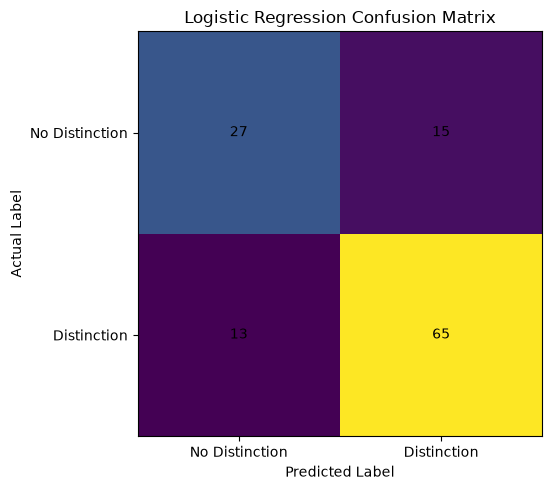

In [34]:
confusion = confusion_matrix(
    y_test_class,
    logistic_predictions
)

fig, ax = plt.subplots(figsize=(7, 5))

image = ax.imshow(confusion)

ax.set_title("Logistic Regression Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "No Distinction",
    "Distinction"
])

ax.set_yticklabels([
    "No Distinction",
    "Distinction"
])

for i in range(confusion.shape[0]):
    for j in range(confusion.shape[1]):
        ax.text(
            j,
            i,
            confusion[i, j],
            ha="center",
            va="center"
        )

fig.tight_layout()

chart_path = output_dir / "logistic_regression_confusion_matrix.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
logistic_comparison = f"""
### 8.1 Finding

The Logistic Regression model achieved an **accuracy of {logistic_accuracy:.6f}**,
**precision of {logistic_precision:.6f}**, **recall of {logistic_recall:.6f}**,
and **F1 score of {logistic_f1:.6f}**.

Compared with the majority-class baseline, Logistic Regression changed
accuracy by **{accuracy_improvement:+.6f}**, precision by
**{precision_improvement:+.6f}**, recall by **{recall_improvement:+.6f}**,
and F1 by **{f1_improvement:+.6f}**.

The model improved accuracy, precision, and F1, while recall decreased by
**{abs(recall_improvement):.6f}**. This shows that Logistic Regression
provides a more balanced classification than simply predicting the majority
class, rather than improving every metric simultaneously.
"""

display(Markdown(logistic_comparison))


### 8.1 Finding

The Logistic Regression model achieved an **accuracy of 0.766667**,
**precision of 0.812500**, **recall of 0.833333**,
and **F1 score of 0.822785**.

Compared with the majority-class baseline, Logistic Regression changed
accuracy by **+0.116667**, precision by
**+0.162500**, recall by **-0.166667**,
and F1 by **+0.034906**.

The model improved accuracy, precision, and F1, while recall decreased by
**0.166667**. This shows that Logistic Regression
provides a more balanced classification than simply predicting the majority
class, rather than improving every metric simultaneously.


# 9. Reproducibility Check

The complete notebook is organized as a single reproducible ML pipeline.

The workflow starts with deterministic dataset generation, applies feature
engineering, creates fixed train/test splits, trains regression and
classification baselines, trains the real models, evaluates their performance,
and interprets the results.

All random operations use fixed seeds so that the same results are obtained
when the notebook is executed from a fresh kernel.

## 9.1 Check Random Seeds

The synthetic dataset uses `seed=21`, while the train/test splits use
`random_state=42`.

The regression split is created without stratification because `exam_score`
is continuous. The classification split uses `stratify=y_classification` so
that the distinction/non-distinction class proportions are preserved in both
the training and test sets.

The Logistic Regression model also uses a fixed `random_state=42`.

## 9.2 Final Pipeline Verification

The notebook should execute successfully from the first cell to the last
without requiring cells to be run manually in a different order.

The final verification checks that both real models have been trained and that
their evaluation metrics are available.

In [36]:
pipeline_verification = f"""
### 9.3 Finding

The regression pipeline produced a Linear Regression **RMSE of
{linear_rmse:.6f}** and **R² of {linear_r2:.6f}**.

The classification pipeline produced a Logistic Regression **accuracy of
{logistic_accuracy:.6f}**, **precision of {logistic_precision:.6f}**,
**recall of {logistic_recall:.6f}**, and **F1 score of {logistic_f1:.6f}**.

All required models, predictions, and evaluation metrics are available after
executing the notebook from top to bottom.
"""

display(Markdown(pipeline_verification))


### 9.3 Finding

The regression pipeline produced a Linear Regression **RMSE of
7.058469** and **R² of 0.525687**.

The classification pipeline produced a Logistic Regression **accuracy of
0.766667**, **precision of 0.812500**,
**recall of 0.833333**, and **F1 score of 0.822785**.

All required models, predictions, and evaluation metrics are available after
executing the notebook from top to bottom.


# 10. Decision Tree — Unconstrained

The first model iteration is an unconstrained Decision Tree Regressor trained
on the same regression features, target, and train/test split established in
Wednesday's pipeline.

The tree is intentionally left unconstrained by not specifying a maximum
depth. This allows the model to grow freely and provides a concrete way to
observe overfitting through the difference between its training and test
performance.

The model will be evaluated using RMSE on both the training and test sets,
along with R² on the test set. A substantially lower training error than test
error would indicate that the tree is fitting the training data more closely
than it generalizes to unseen observations.

## 10.1 Train the Unconstrained Decision Tree

The Decision Tree Regressor is trained using the same `X_train` and `y_train`
created in the regression train/test split from Wednesday.

No `max_depth` constraint is applied at this stage. This is deliberate: the
goal is to observe how an unrestricted tree behaves before introducing a
complexity constraint.

In [37]:

tree_regressor = DecisionTreeRegressor(
    random_state=42
)

tree_regressor.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

## 10.2 Generate Predictions

Predictions are generated for both the training and held-out test sets.

The training predictions allow us to measure how closely the unconstrained
tree fits the observations it learned from. The test predictions provide the
unseen-data performance needed to evaluate generalization.

In [38]:
tree_train_predictions = tree_regressor.predict(X_train)
tree_test_predictions = tree_regressor.predict(X_test)

## 10.3 Evaluate Training and Test Performance

RMSE is calculated on both datasets so that the model's training fit can be
compared directly with its performance on unseen observations.

Test-set R² is also calculated to measure how much of the variation in the
held-out exam scores is explained by the model relative to the mean-prediction
baseline.

In [39]:
tree_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        tree_train_predictions
    )
)

tree_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tree_test_predictions
    )
)

tree_test_r2 = r2_score(
    y_test,
    tree_test_predictions
)

## 10.4 Finding

The following finding reports the unconstrained tree's training and test
performance dynamically from the calculated metrics. Comparing the two RMSE
values provides direct evidence of whether the model is fitting the training
data substantially more closely than the unseen test data.

In [40]:
tree_overfitting_finding = f"""

The unconstrained Decision Tree achieved a training RMSE of
**{tree_train_rmse:.6f}** and a test RMSE of **{tree_test_rmse:.6f}**,
with a test R² of **{tree_test_r2:.6f}**.

The training-to-test RMSE gap is
**{tree_test_rmse - tree_train_rmse:.6f}**.

The difference between training and test performance provides evidence of
{'overfitting, because the model fits the training data substantially more closely than the unseen test data'
if tree_test_rmse > tree_train_rmse
else
'limited overfitting, because the training and test errors are relatively close'}.
"""

display(Markdown(tree_overfitting_finding))



The unconstrained Decision Tree achieved a training RMSE of
**0.000000** and a test RMSE of **9.535998**,
with a test R² of **0.134282**.

The training-to-test RMSE gap is
**9.535998**.

The difference between training and test performance provides evidence of
overfitting, because the model fits the training data substantially more closely than the unseen test data.


# 11. Constrained Decision Tree

The unconstrained Decision Tree from Section 10 produced a training RMSE of
zero while performing substantially worse on the held-out test set. This
indicates that the unrestricted tree was able to fit the training observations
too closely.

To reduce this complexity, the tree is now constrained using `max_depth=3`.
The purpose is not simply to obtain a lower training error, but to test whether
restricting the tree's complexity improves its ability to generalize to unseen
data.

The constrained tree will be compared with the unconstrained Decision Tree
and Wednesday's Linear Regression model using test RMSE and R².

## 11.1 Train the Depth-3 Decision Tree

A maximum depth of three limits the number of sequential decisions the tree
can make. This prevents the model from creating an increasingly detailed set
of splits that can memorize individual training observations.

The same regression features, target, and train/test split from Wednesday are
used so that the comparison with the previous models remains fair.

In [41]:
tree_depth3 = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

tree_depth3.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

## 11.2 Generate Predictions

Predictions are generated for both the training and test sets. Comparing the
two sets of predictions allows us to observe whether limiting tree depth
reduces the gap between training and test performance.

In [42]:
tree_depth3_train_predictions = tree_depth3.predict(X_train)
tree_depth3_test_predictions = tree_depth3.predict(X_test)

## 11.3 Evaluate the Constrained Tree

The constrained tree is evaluated using RMSE on both the training and test
sets and R² on the test set.

The main comparison is whether the depth constraint produces a more balanced
relationship between training performance and test performance than the
unconstrained tree.

In [43]:
tree_depth3_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        tree_depth3_train_predictions
    )
)

tree_depth3_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tree_depth3_test_predictions
    )
)

tree_depth3_test_r2 = r2_score(
    y_test,
    tree_depth3_test_predictions
)

## 11.4 Compare Regression Test Performance

The constrained tree is compared with the unconstrained Decision Tree and
Wednesday's Linear Regression using the same held-out test set.

Lower RMSE indicates smaller prediction errors, while higher R² indicates
that the model explains more variation in the test target relative to the
mean-prediction baseline.

In [44]:
tree_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree — Unconstrained",
        "Decision Tree — Depth 3"
    ],
    "Test RMSE": [
        linear_rmse,
        tree_test_rmse,
        tree_depth3_test_rmse
    ],
    "Test R²": [
        linear_r2,
        tree_test_r2,
        tree_depth3_test_r2
    ]
})

display(tree_comparison)

,Model,Test RMSE,Test R²
0,Linear Regression,7.058469,0.525687
1,Decision Tree — Unconstrained,9.535998,0.134282
2,Decision Tree — Depth 3,7.103141,0.519664


## 11.5 Training vs Test RMSE

The following visualization compares training and test RMSE for the
unconstrained and depth-3 Decision Trees.

The purpose is to make the effect of constraining model complexity visible:
an effective constraint should reduce the extreme difference between training
and test performance, even if it increases the training error.

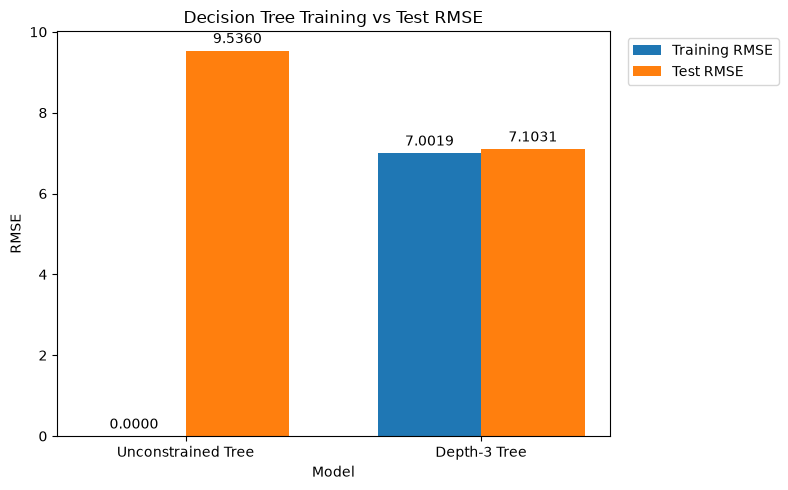

In [45]:
tree_rmse_comparison = pd.DataFrame({

    "Model": [
        "Unconstrained Tree",
        "Depth-3 Tree"
    ],

    "Training RMSE": [
        tree_train_rmse,
        tree_depth3_train_rmse
    ],

    "Test RMSE": [
        tree_test_rmse,
        tree_depth3_test_rmse
    ]

})

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(tree_rmse_comparison))

width = 0.35

training_bars = ax.bar(
    x - width / 2,
    tree_rmse_comparison["Training RMSE"],
    width,
    label="Training RMSE"
)

test_bars = ax.bar(
    x + width / 2,
    tree_rmse_comparison["Test RMSE"],
    width,
    label="Test RMSE"
)

ax.bar_label(
    training_bars,
    fmt="%.4f",
    padding=3
)

ax.bar_label(
    test_bars,
    fmt="%.4f",
    padding=3
)

ax.set_title("Decision Tree Training vs Test RMSE")

ax.set_xlabel("Model")

ax.set_ylabel("RMSE")

ax.set_xticks(x)

ax.set_xticklabels(tree_rmse_comparison["Model"])

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

fig.tight_layout()

chart_path = output_dir / "decision_tree_training_vs_test_rmse.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 11.6 Finding

The following comparison evaluates whether constraining the Decision Tree
improved generalization relative to the unconstrained tree and how both tree
models compare with Wednesday's Linear Regression.

In [46]:
tree_depth3_finding = f"""

The depth-3 Decision Tree achieved a training RMSE of
**{tree_depth3_train_rmse:.6f}** and a test RMSE of
**{tree_depth3_test_rmse:.6f}**, with a test R² of
**{tree_depth3_test_r2:.6f}**.

In comparison, the unconstrained Decision Tree achieved a training RMSE of
**{tree_train_rmse:.6f}** and a test RMSE of **{tree_test_rmse:.6f}**,
with a test R² of **{tree_test_r2:.6f}**.

Wednesday's Linear Regression achieved a test RMSE of
**{linear_rmse:.6f}** and a test R² of **{linear_r2:.6f}**.

The depth-3 constraint changed the training RMSE by
**{tree_depth3_train_rmse - tree_train_rmse:.6f}** and the test RMSE by
**{tree_depth3_test_rmse - tree_test_rmse:.6f}** relative to the
unconstrained tree. This shows whether reducing tree complexity improved
generalization on the held-out data rather than simply improving training fit.
"""

display(Markdown(tree_depth3_finding))



The depth-3 Decision Tree achieved a training RMSE of
**7.001867** and a test RMSE of
**7.103141**, with a test R² of
**0.519664**.

In comparison, the unconstrained Decision Tree achieved a training RMSE of
**0.000000** and a test RMSE of **9.535998**,
with a test R² of **0.134282**.

Wednesday's Linear Regression achieved a test RMSE of
**7.058469** and a test R² of **0.525687**.

The depth-3 constraint changed the training RMSE by
**7.001867** and the test RMSE by
**-2.432857** relative to the
unconstrained tree. This shows whether reducing tree complexity improved
generalization on the held-out data rather than simply improving training fit.


# 12. Random Forest

The next model iteration is a Random Forest, an ensemble of multiple decision
trees. Instead of relying on a single tree, the forest combines predictions
from many trees to produce a more stable model.

For the regression task, a Random Forest Regressor with 200 trees is trained
on the same features, target, and train/test split used by the previous
regression models. Its RMSE and R² are compared with the existing models.

The forest's feature importances are also examined and compared with the
Linear Regression coefficients from Wednesday. These two measures describe
feature influence differently and should therefore be interpreted rather than
treated as equivalent quantities.

For the classification task, a Random Forest Classifier is trained on the
same `distinction` target and classification split used by Logistic
Regression. Accuracy, precision, recall, and F1 are then compared directly
with the Logistic Regression results.

## 12.1 Train the Regression Forest

The Random Forest Regressor is trained using the same regression training
data used by Linear Regression and both Decision Tree models.

The forest contains 200 decision trees. A fixed random state is used to keep
the experiment reproducible.

In [47]:

random_forest_regressor = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

random_forest_regressor.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

### 12.1.1 Generate Predictions

Predictions are generated on the held-out regression test set so that the
Random Forest can be evaluated using the same unseen observations used by the
previous regression models.

In [48]:
forest_regression_predictions = random_forest_regressor.predict(X_test)

### 12.1.2 Evaluate the Regression Forest

The Random Forest Regressor is evaluated using RMSE and R² on the regression
test set.

RMSE measures the typical magnitude of prediction error in the same units as
the exam score, while R² measures the proportion of target variation
explained relative to the mean-prediction baseline.

In [49]:
forest_regression_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        forest_regression_predictions
    )
)

forest_regression_r2 = r2_score(
    y_test,
    forest_regression_predictions
)

### 12.1.3 Finding

The Random Forest's test performance is reported dynamically so that the
evaluation remains reproducible when the notebook is rerun.

In [50]:
forest_regression_finding = f"""
The Random Forest Regressor achieved a test RMSE of
**{forest_regression_rmse:.6f}** and a test R² of
**{forest_regression_r2:.6f}**.

These metrics will be compared with Linear Regression, the unconstrained
Decision Tree, and the depth-3 Decision Tree in the model comparison section.
A lower RMSE and higher R² indicate stronger test-set performance.
"""

display(Markdown(forest_regression_finding))


The Random Forest Regressor achieved a test RMSE of
**7.354371** and a test R² of
**0.485085**.

These metrics will be compared with Linear Regression, the unconstrained
Decision Tree, and the depth-3 Decision Tree in the model comparison section.
A lower RMSE and higher R² indicate stronger test-set performance.


In [51]:
random_forest_regressor.feature_importances_

array([0.6305789 , 0.17121332, 0.15159612, 0.01472268, 0.03188898])

### 12.1.4 Feature Importance

The Random Forest provides a feature importance value for each input
feature. These values indicate the relative contribution of features to the
forest's tree-based splitting decisions.

The values are displayed alongside the feature names so that the most heavily
used features can be identified and compared with the strongest Linear
Regression coefficient from Wednesday.

In [52]:
forest_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Random Forest Importance": random_forest_regressor.feature_importances_
}).sort_values(
    "Random Forest Importance",
    ascending=False
)

display(forest_feature_importance)

,Feature,Random Forest Importance
0,study_hours_per_week,0.630579
1,sleep_hours_per_night,0.171213
2,attendance_pct,0.151596
4,class_section_C,0.031889
3,class_section_B,0.014723


### 12.1.5 Feature Importance Visualization

The feature importance chart ranks the input features according to their
relative importance in the Random Forest. This makes it easier to identify
which predictors the ensemble relies on most heavily.

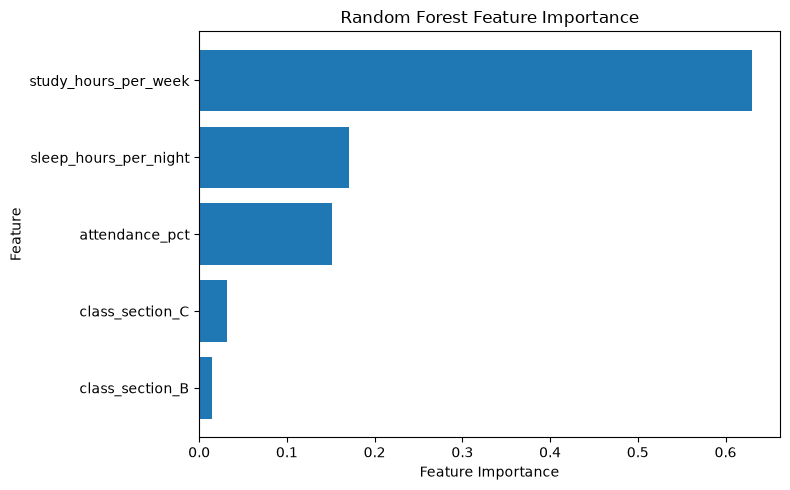

In [53]:
fig, ax = plt.subplots(figsize=(8, 5))

importance_plot = forest_feature_importance.sort_values(
    "Random Forest Importance"
)

ax.barh(
    importance_plot["Feature"],
    importance_plot["Random Forest Importance"]
)

ax.set_title("Random Forest Feature Importance")
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")

fig.tight_layout()

chart_path = output_dir / "random_forest_feature_importance.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 12.1.6 Compare Feature Influence Across Models

Linear Regression and Random Forest describe feature influence differently.
Linear Regression coefficients represent the estimated change in the
prediction associated with a one-unit feature change while holding the other
features fixed within the linear model.

Random Forest feature importance instead reflects the relative contribution of
features to the tree ensemble's splitting decisions.

The comparison therefore focuses on which features each model identifies as
most influential rather than treating their numerical values as directly
equivalent.

In [54]:
linear_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Linear Regression Coefficient": linear_model.coef_
})

linear_coefficients["Absolute Coefficient"] = (
    linear_coefficients["Linear Regression Coefficient"].abs()
)

strongest_linear_feature = linear_coefficients.loc[
    linear_coefficients["Absolute Coefficient"].idxmax(),
    "Feature"
]

strongest_forest_feature = forest_feature_importance.iloc[0]["Feature"]

display(
    linear_coefficients.sort_values(
        "Absolute Coefficient",
        ascending=False
    )
)

,Feature,Linear Regression Coefficient,Absolute Coefficient
4,class_section_C,3.130411,3.130411
0,study_hours_per_week,2.032968,2.032968
3,class_section_B,0.124746,0.124746
2,attendance_pct,0.088653,0.088653
1,sleep_hours_per_night,-0.009430,0.009430


In [55]:
forest_feature_comparison = f"""
### 12.1.7 Finding

The feature with the largest absolute Linear Regression coefficient is
**{strongest_linear_feature}**, while the Random Forest assigns its highest
feature importance to **{strongest_forest_feature}**.

The two measures should not be interpreted as equivalent quantities: the
Linear Regression coefficient represents a directional linear effect, whereas
Random Forest feature importance represents relative contribution to the
forest's tree-based splits.

The comparison therefore shows whether both model types identify similar
predictive features or rely on different aspects of the feature space.
"""

display(Markdown(forest_feature_comparison))


### 12.1.7 Finding

The feature with the largest absolute Linear Regression coefficient is
**class_section_C**, while the Random Forest assigns its highest
feature importance to **study_hours_per_week**.

The two measures should not be interpreted as equivalent quantities: the
Linear Regression coefficient represents a directional linear effect, whereas
Random Forest feature importance represents relative contribution to the
forest's tree-based splits.

The comparison therefore shows whether both model types identify similar
predictive features or rely on different aspects of the feature space.


## 12.2 Random Forest Classifier

The classification side of the pipeline is extended with a Random Forest
Classifier trained on the same `distinction` target and stratified
train/test split used by Logistic Regression.

The model is evaluated using accuracy, precision, recall, and F1 so that its
performance can be compared directly with the Logistic Regression model from
Wednesday.

### 12.2.1 Train the Classification Forest

The Random Forest Classifier is trained using the same classification
features and stratified training split used for the previous classifier.

A fixed random state is used to maintain reproducibility.

In [56]:

random_forest_classifier = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

random_forest_classifier.fit(
    X_train_class,
    y_train_class
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

### 12.2.2 Generate Predictions

Predictions are generated for the held-out classification test set. The
resulting labels will be evaluated using the same four classification metrics
used for Logistic Regression.

In [57]:
forest_classification_predictions = random_forest_classifier.predict(
    X_test_class
)

### 12.2.3 Evaluate the Classification Forest

The Random Forest Classifier is evaluated using accuracy, precision, recall,
and F1. Using all four metrics prevents the comparison from depending on
accuracy alone and allows different aspects of classification performance to
be considered.

In [58]:
forest_accuracy = accuracy_score(
    y_test_class,
    forest_classification_predictions
)

forest_precision = precision_score(
    y_test_class,
    forest_classification_predictions
)

forest_recall = recall_score(
    y_test_class,
    forest_classification_predictions
)

forest_f1 = f1_score(
    y_test_class,
    forest_classification_predictions
)

### 12.2.4 Compare with Logistic Regression

The Random Forest metrics are compared directly with Wednesday's Logistic
Regression metrics using the same classification test set.

The comparison identifies whether the more complex ensemble provides a
measurable improvement across accuracy, precision, recall, and F1.

In [59]:
classification_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        forest_accuracy
    ],
    "Precision": [
        logistic_precision,
        forest_precision
    ],
    "Recall": [
        logistic_recall,
        forest_recall
    ],
    "F1": [
        logistic_f1,
        forest_f1
    ]
})

display(classification_model_comparison)

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.766667,0.8125,0.833333,0.822785
1,Random Forest,0.733333,0.7875,0.807692,0.797468


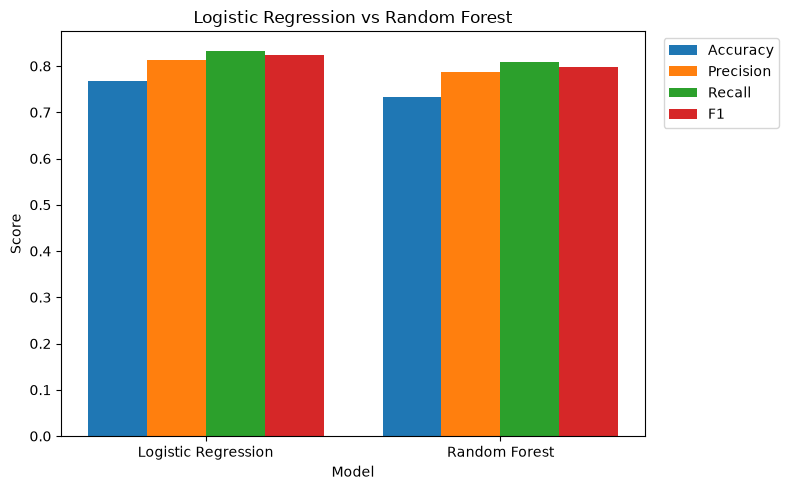

In [60]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(classification_model_comparison))
width = 0.2

metrics = ["Accuracy", "Precision", "Recall", "F1"]

for i, metric in enumerate(metrics):
    ax.bar(
        x + (i - 1.5) * width,
        classification_model_comparison[metric],
        width,
        label=metric
    )

ax.set_title("Logistic Regression vs Random Forest")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(classification_model_comparison["Model"])

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

fig.tight_layout()

chart_path = output_dir / "classification_logistic_vs_random_forest.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 12.2.5 Finding

The following finding summarizes how the Random Forest compares with Logistic
Regression across all four classification metrics. The values are generated
directly from the evaluated models so that the conclusion remains reproducible.

In [61]:
forest_classification_finding = f"""

The Random Forest achieved an accuracy of **{forest_accuracy:.6f}**,
precision of **{forest_precision:.6f}**, recall of **{forest_recall:.6f}**,
and F1 of **{forest_f1:.6f}**.

Logistic Regression achieved an accuracy of **{logistic_accuracy:.6f}**,
precision of **{logistic_precision:.6f}**, recall of **{logistic_recall:.6f}**,
and F1 of **{logistic_f1:.6f}**.

Compared with Logistic Regression, the Random Forest changed accuracy by
**{forest_accuracy - logistic_accuracy:.6f}**, precision by
**{forest_precision - logistic_precision:.6f}**, recall by
**{forest_recall - logistic_recall:.6f}**, and F1 by
**{forest_f1 - logistic_f1:.6f}**.

These differences will be considered alongside the regression results and
error analysis before selecting the final models.
"""

display(Markdown(forest_classification_finding))



The Random Forest achieved an accuracy of **0.733333**,
precision of **0.787500**, recall of **0.807692**,
and F1 of **0.797468**.

Logistic Regression achieved an accuracy of **0.766667**,
precision of **0.812500**, recall of **0.833333**,
and F1 of **0.822785**.

Compared with Logistic Regression, the Random Forest changed accuracy by
**-0.033333**, precision by
**-0.025000**, recall by
**-0.025641**, and F1 by
**-0.025316**.

These differences will be considered alongside the regression results and
error analysis before selecting the final models.


## 12.3 Decision Tree Classifier

The classification pipeline is also extended with a Decision Tree Classifier.
The model uses the same classification features and stratified train/test
split used by Logistic Regression and the Random Forest Classifier.

The Decision Tree is included as an additional model so that the final
classification comparison evaluates both a single tree and the ensemble
Random Forest against the simpler Logistic Regression and majority-class
baseline.

### 12.3.1 Train the Decision Tree Classifier

The Decision Tree Classifier is trained without a depth constraint so that its
classification performance can be compared with the other models using the
same held-out test data.

In [62]:

tree_classifier = DecisionTreeClassifier(
    random_state=42
)

tree_classifier.fit(
    X_train_class,
    y_train_class
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

### 12.3.2 Evaluate the Decision Tree Classifier

The Decision Tree Classifier is evaluated using accuracy, precision, recall,
and F1. These are the same metrics used for Logistic Regression and the
Random Forest Classifier, allowing a direct comparison across all
classification models.

In [63]:
tree_classification_predictions = tree_classifier.predict(
    X_test_class
)

tree_classifier_accuracy = accuracy_score(
    y_test_class,
    tree_classification_predictions
)

tree_classifier_precision = precision_score(
    y_test_class,
    tree_classification_predictions
)

tree_classifier_recall = recall_score(
    y_test_class,
    tree_classification_predictions
)

tree_classifier_f1 = f1_score(
    y_test_class,
    tree_classification_predictions
)

### 12.3.3 Finding

The Decision Tree Classifier's performance is reported using the same four
metrics as the other classification models. These results will be included
in the final model comparison.

In [64]:
tree_classifier_finding = f"""

The Decision Tree Classifier achieved an accuracy of
**{tree_classifier_accuracy:.6f}**, precision of
**{tree_classifier_precision:.6f}**, recall of
**{tree_classifier_recall:.6f}**, and F1 of
**{tree_classifier_f1:.6f}**.

These results provide the missing single-tree comparison needed before
selecting the final classification model.
"""

display(Markdown(tree_classifier_finding))



The Decision Tree Classifier achieved an accuracy of
**0.708333**, precision of
**0.786667**, recall of
**0.756410**, and F1 of
**0.771242**.

These results provide the missing single-tree comparison needed before
selecting the final classification model.


# 13. Model Comparison and Final Choice

The models developed across Wednesday and Thursday are now compared using
their held-out test-set performance.

For regression, the comparison includes the mean-prediction baseline,
Linear Regression, the unconstrained Decision Tree, the depth-3 Decision
Tree, and the Random Forest Regressor.

For classification, the comparison includes the majority-class baseline,
Logistic Regression, the Decision Tree Classifier, and the Random Forest
Classifier.

The purpose of this comparison is to select models based on observed
generalization performance rather than assuming that a more complex model is
automatically better.

## 13.1 Regression Model Comparison

The regression models are compared using RMSE and R² on the same held-out
test set. RMSE measures prediction error in exam-score units, so lower values
are preferred. R² measures explained variation relative to the
mean-prediction baseline, so higher values are preferred.

In [65]:
regression_comparison = pd.DataFrame({
    "Model": [
        "Mean Baseline",
        "Linear Regression",
        "Decision Tree — Unconstrained",
        "Decision Tree — Depth 3",
        "Random Forest"
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        tree_test_rmse,
        tree_depth3_test_rmse,
        forest_regression_rmse
    ],
    "R²": [
        baseline_r2,
        linear_r2,
        tree_test_r2,
        tree_depth3_test_r2,
        forest_regression_r2
    ]
})

display(regression_comparison)

,Model,RMSE,R²
0,Mean Baseline,10.297789,-0.009560
1,Linear Regression,7.058469,0.525687
2,Decision Tree — Unconstrained,9.535998,0.134282
3,Decision Tree — Depth 3,7.103141,0.519664
4,Random Forest,7.354371,0.485085


## 13.2 Classification Model Comparison

The classification models are compared using accuracy, precision, recall, and
F1 on the same held-out classification test set.

Accuracy measures overall correctness, while precision measures the reliability
of positive predictions and recall measures how many actual positive cases
are identified. F1 provides a single measure that balances precision and
recall.

The majority-class baseline is retained as an important reference because a
model should demonstrate useful predictive performance beyond simply
predicting the most common class.

In [66]:
classification_comparison = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        logistic_accuracy,
        tree_classifier_accuracy,
        forest_accuracy
    ],
    "Precision": [
        baseline_precision,
        logistic_precision,
        tree_classifier_precision,
        forest_precision
    ],
    "Recall": [
        baseline_recall,
        logistic_recall,
        tree_classifier_recall,
        forest_recall
    ],
    "F1": [
        baseline_f1,
        logistic_f1,
        tree_classifier_f1,
        forest_f1
    ]
})

display(classification_comparison)

,Model,Accuracy,Precision,Recall,F1
0,Majority Baseline,0.650000,0.650000,1.000000,0.787879
1,Logistic Regression,0.766667,0.812500,0.833333,0.822785
2,Decision Tree,0.708333,0.786667,0.756410,0.771242
3,Random Forest,0.733333,0.787500,0.807692,0.797468


## 13.3 Regression Performance Visualization

The following chart compares the test RMSE of all regression models. Because
RMSE is measured in exam-score units and lower values represent smaller
prediction errors, the model with the lowest bar provides the strongest
performance on this metric.

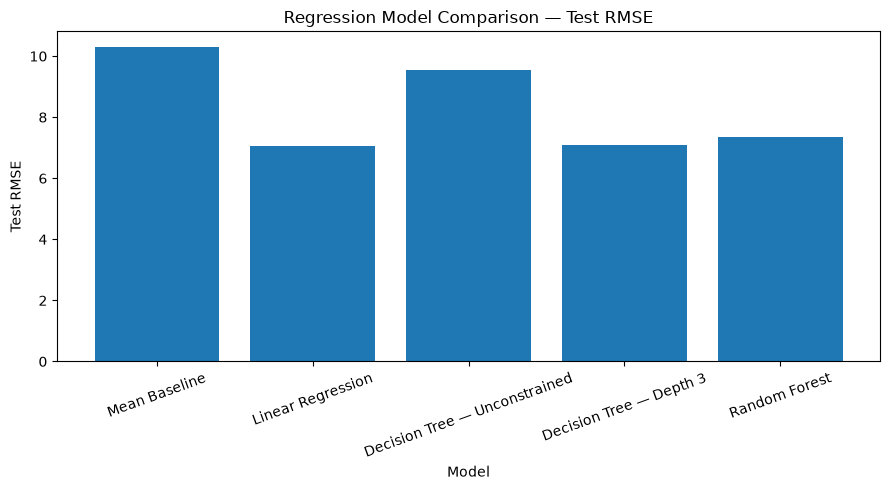

In [67]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    regression_comparison["Model"],
    regression_comparison["RMSE"]
)

ax.set_title("Regression Model Comparison — Test RMSE")
ax.set_xlabel("Model")
ax.set_ylabel("Test RMSE")
ax.tick_params(axis="x", rotation=20)

fig.tight_layout()

chart_path = output_dir / "regression_model_comparison_rmse.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 13.4 Classification Performance Visualization

The classification comparison is visualized across accuracy, precision,
recall, and F1. Examining all four metrics together makes it possible to
identify whether a model provides balanced performance or achieves a strong
result on one metric at the expense of another.

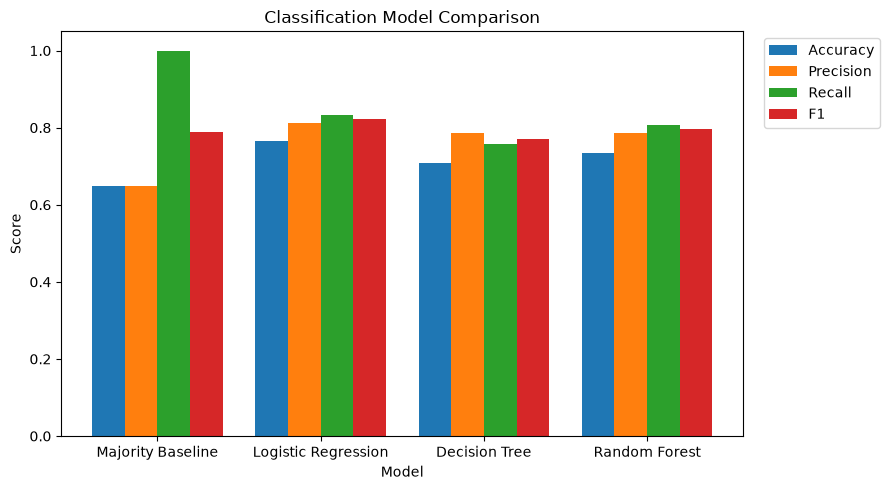

In [68]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(classification_comparison))
width = 0.2

metrics = ["Accuracy", "Precision", "Recall", "F1"]

for i, metric in enumerate(metrics):
    ax.bar(
        x + (i - 1.5) * width,
        classification_comparison[metric],
        width,
        label=metric
    )

ax.set_title("Classification Model Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(classification_comparison["Model"])
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

fig.tight_layout()

chart_path = output_dir / "classification_model_comparison.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 13.5 Regression Model Selection

The regression model with the lowest test RMSE is selected as the candidate
final model. Its R² is also considered to ensure that the lower prediction
error is accompanied by strong explanatory performance on the same held-out
test set.

In [69]:
best_regression_row = regression_comparison.loc[
    regression_comparison["RMSE"].idxmin()
]

best_regression_model = best_regression_row["Model"]
best_regression_rmse = best_regression_row["RMSE"]
best_regression_r2 = best_regression_row["R²"]

regression_winner_finding = f"""
### Finding

The strongest regression model based on the lowest test RMSE is
**{best_regression_model}**, with a test RMSE of
**{best_regression_rmse:.6f}** and a test R² of
**{best_regression_r2:.6f}**.

The selection is based on held-out test performance rather than model
complexity. This means a simpler model is preferred if it generalizes better
than a more complex alternative on this dataset.
"""

display(Markdown(regression_winner_finding))


### Finding

The strongest regression model based on the lowest test RMSE is
**Linear Regression**, with a test RMSE of
**7.058469** and a test R² of
**0.525687**.

The selection is based on held-out test performance rather than model
complexity. This means a simpler model is preferred if it generalizes better
than a more complex alternative on this dataset.


In [70]:
regression_final_decision = f"""
### 13.6 Final Regression Model Decision

I would ship **{best_regression_model}** for the regression task because it
achieved the lowest test RMSE of **{best_regression_rmse:.6f}** and the
highest test R² of **{best_regression_r2:.6f}** among the evaluated regression
models.

Although the Random Forest is more complex, its test RMSE of
**{forest_regression_rmse:.6f}** and R² of **{forest_regression_r2:.6f}** are
worse than Linear Regression. The depth-3 tree performed closely, with a test
RMSE of **{tree_depth3_test_rmse:.6f}**, but still did not surpass the simpler
Linear Regression model.
"""

display(Markdown(regression_final_decision))


### 13.6 Final Regression Model Decision

I would ship **Linear Regression** for the regression task because it
achieved the lowest test RMSE of **7.058469** and the
highest test R² of **0.525687** among the evaluated regression
models.

Although the Random Forest is more complex, its test RMSE of
**7.354371** and R² of **0.485085** are
worse than Linear Regression. The depth-3 tree performed closely, with a test
RMSE of **7.103141**, but still did not surpass the simpler
Linear Regression model.


## 13.7 Classification Model Selection

The classification models are compared using all four evaluation metrics.
F1 is used as the primary selection metric because it balances precision and
recall, while accuracy, precision, and recall provide additional evidence
about the model's behavior.

The final choice should therefore reflect the overall metric profile rather
than selecting a model solely because it has the highest accuracy.

In [71]:
best_classification_row = classification_comparison.loc[
    classification_comparison["F1"].idxmax()
]

best_classification_model = best_classification_row["Model"]
best_classification_accuracy = best_classification_row["Accuracy"]
best_classification_precision = best_classification_row["Precision"]
best_classification_recall = best_classification_row["Recall"]
best_classification_f1 = best_classification_row["F1"]

classification_winner_finding = f"""
### 13.8 Finding

The strongest classification model based on F1 is
**{best_classification_model}**, with an accuracy of
**{best_classification_accuracy:.6f}**, precision of
**{best_classification_precision:.6f}**, recall of
**{best_classification_recall:.6f}**, and F1 of
**{best_classification_f1:.6f}**.

The model is selected based on its overall precision-recall balance rather
than model complexity or accuracy alone. The remaining metrics will also be
considered during error analysis and calibration before the final pipeline
is defended.
"""

display(Markdown(classification_winner_finding))


### 13.8 Finding

The strongest classification model based on F1 is
**Logistic Regression**, with an accuracy of
**0.766667**, precision of
**0.812500**, recall of
**0.833333**, and F1 of
**0.822785**.

The model is selected based on its overall precision-recall balance rather
than model complexity or accuracy alone. The remaining metrics will also be
considered during error analysis and calibration before the final pipeline
is defended.


In [72]:
classification_final_decision = f"""
### 13.9 Final Classification Model Decision

I would ship **{best_classification_model}** for the classification task
because it achieved the highest F1 of **{best_classification_f1:.6f}**, along
with the highest accuracy of **{best_classification_accuracy:.6f}**,
precision of **{best_classification_precision:.6f}**, and recall of
**{best_classification_recall:.6f}**.

The Random Forest is more complex but achieved a lower F1 of
**{forest_f1:.6f}** and lower accuracy of **{forest_accuracy:.6f}**, so the
additional complexity does not provide better predictive performance on this
dataset.
"""

display(Markdown(classification_final_decision))


### 13.9 Final Classification Model Decision

I would ship **Logistic Regression** for the classification task
because it achieved the highest F1 of **0.822785**, along
with the highest accuracy of **0.766667**,
precision of **0.812500**, and recall of
**0.833333**.

The Random Forest is more complex but achieved a lower F1 of
**0.797468** and lower accuracy of **0.733333**, so the
additional complexity does not provide better predictive performance on this
dataset.


# 14. Error Analysis

Overall evaluation metrics summarize model performance across the entire test
set, but they do not reveal which individual observations are difficult to
predict.

This section examines the errors made by the selected models directly. For
regression, the analysis focuses on the five test observations with the
largest absolute residuals. For classification, the analysis examines the
observations that were misclassified by Logistic Regression.

The feature values of these observations are inspected for common patterns,
such as unusual study hours, attendance levels, or class sections. The
analysis does not assume that a pattern exists; the conclusion is based on
the observations actually identified by the models.

## 14.1 Regression Error Analysis

Linear Regression was selected as the final regression model because it
achieved the strongest held-out test performance among the evaluated
regression models.

To examine where this model performs poorly, a residual is calculated for
every test-set observation as the actual exam score minus the predicted exam
score.

The absolute residual is then used to rank the observations because both
large positive and large negative prediction errors represent large mistakes.
The five observations with the largest absolute residuals will be inspected
directly.

In [73]:
regression_error_analysis = X_test.copy()

regression_error_analysis["actual_exam_score"] = y_test
regression_error_analysis["predicted_exam_score"] = linear_predictions

regression_error_analysis["residual"] = (
    regression_error_analysis["actual_exam_score"]
    - regression_error_analysis["predicted_exam_score"]
)

regression_error_analysis["absolute_residual"] = (
    regression_error_analysis["residual"].abs()
)

regression_error_analysis = regression_error_analysis.sort_values(
    "absolute_residual",
    ascending=False
)

### 14.1.2 Five Largest Regression Errors

The five observations with the largest absolute residuals are displayed below.
The feature values are retained alongside the actual and predicted exam
scores so that the characteristics of these difficult observations can be
examined directly.

In [74]:
worst_regression_errors = regression_error_analysis.head(5)

display(worst_regression_errors)

,study_hours_per_week,sleep_hours_per_night,attendance_pct,class_section_B,class_section_C,actual_exam_score,predicted_exam_score,residual,absolute_residual
575,8.9,8.503745,75.3,False,False,65.3,84.115613,-18.815613,18.815613
515,13.9,9.961220,74.3,True,False,76.0,94.302800,-18.302800,18.302800
70,6.8,7.615322,87.1,False,False,98.4,80.900859,17.499141,17.499141
506,7.6,5.492850,87.7,False,False,100.0,82.600440,17.399560,17.399560
257,7.0,6.257330,69.3,False,True,99.5,82.872653,16.627347,16.627347


In [75]:
linear_predictions_series = pd.Series(
    linear_predictions,
    index=X_test.index,
    name="predicted_exam_score"
)

worst_regression_errors = students.loc[
    regression_error_analysis.head(5).index,
    [
        "student_id",
        "class_section",
        "study_hours_per_week",
        "sleep_hours_per_night",
        "attendance_pct",
        "exam_score"
    ]
].copy()

worst_regression_errors["predicted_exam_score"] = (
    linear_predictions_series.loc[
        worst_regression_errors.index
    ]
)

worst_regression_errors["residual"] = (
    worst_regression_errors["exam_score"]
    - worst_regression_errors["predicted_exam_score"]
)

worst_regression_errors["absolute_residual"] = (
    worst_regression_errors["residual"].abs()
)

worst_regression_errors = worst_regression_errors.sort_values(
    "absolute_residual",
    ascending=False
)

display(worst_regression_errors)

,student_id,class_section,study_hours_per_week,sleep_hours_per_night,attendance_pct,exam_score,predicted_exam_score,residual,absolute_residual
575,576,A,8.9,8.503745,75.3,65.3,84.115613,-18.815613,18.815613
515,516,B,13.9,9.961220,74.3,76.0,94.302800,-18.302800,18.302800
70,71,A,6.8,7.615322,87.1,98.4,80.900859,17.499141,17.499141
506,507,A,7.6,5.492850,87.7,100.0,82.600440,17.399560,17.399560
257,258,C,7.0,6.257330,69.3,99.5,82.872653,16.627347,16.627347


## 14.2 Visualize the Five Largest Regression Errors

The following chart shows the absolute residual for the five observations that
Linear Regression predicted most inaccurately.

Larger bars represent larger prediction errors. The visualization complements
the feature-level table by showing the magnitude of each selected error.

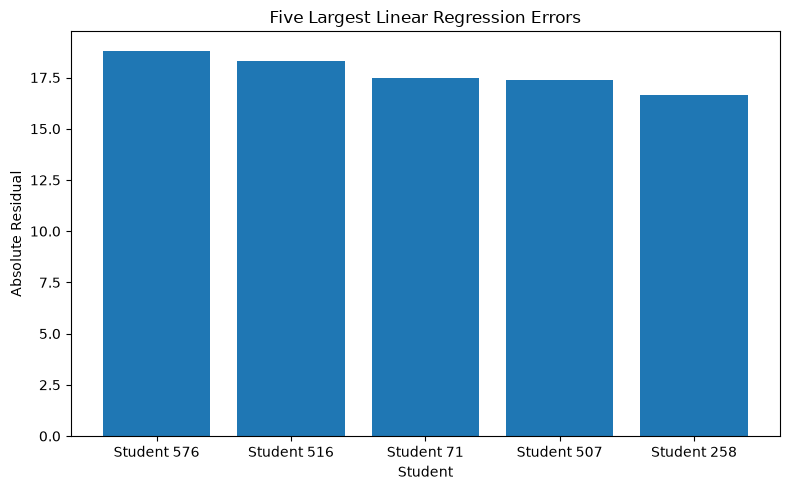

In [76]:
fig, ax = plt.subplots(figsize=(8, 5))

error_labels = (
    "Student "
    + worst_regression_errors["student_id"].astype(str)
)

ax.bar(
    error_labels,
    worst_regression_errors["absolute_residual"]
)

ax.set_title("Five Largest Linear Regression Errors")
ax.set_xlabel("Student")
ax.set_ylabel("Absolute Residual")

fig.tight_layout()

chart_path = output_dir / "linear_regression_worst_errors.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 14.3 Regression Error Pattern

The five largest regression errors are inspected for shared characteristics.
Particular attention is given to class section, study hours, attendance, and
sleep because these are the predictors available to the model.

The finding below should be based on the actual observations rather than on an
assumption about how the data was generated.

### 14.3.1 Finding

The five largest Linear Regression errors were inspected directly to identify
common characteristics in the observations that the model predicts poorly.

The analysis focuses on prediction direction, attendance, actual exam scores,
and class section. Because only five observations are examined, any observed
pattern should be treated as an indication of where the model may struggle
rather than as a general rule for the entire dataset.

In [77]:
worst_errors_count = len(worst_regression_errors)

underpredicted_count = (
    worst_regression_errors["residual"] > 0
).sum()

overpredicted_count = (
    worst_regression_errors["residual"] < 0
).sum()

high_score_underpredictions = worst_regression_errors[
    (worst_regression_errors["residual"] > 0)
    & (worst_regression_errors["exam_score"] >= 95)
]

section_counts = (
    worst_regression_errors["class_section"]
    .value_counts()
)

most_common_error_section = section_counts.index[0]
most_common_error_section_count = section_counts.iloc[0]

regression_error_finding = f"""

Among the **{worst_errors_count}** largest regression errors, the model
underpredicted **{underpredicted_count}** observations and overpredicted
**{overpredicted_count}** observations.

A notable pattern is that **{len(high_score_underpredictions)}** of the
largest errors were underpredictions for students whose actual exam score
was at least 95. This indicates that the Linear Regression model can
substantially underestimate unusually high exam scores even when the
available feature values suggest more moderate outcomes.

The errors do not appear to be explained by a single class section:
the most common section among these observations was
**{most_common_error_section}**, appearing **{most_common_error_section_count}**
times out of five. The inspected errors therefore suggest that the model's
largest mistakes are more closely associated with unusual outcomes than with
one specific section.
"""

display(Markdown(regression_error_finding))



Among the **5** largest regression errors, the model
underpredicted **3** observations and overpredicted
**2** observations.

A notable pattern is that **3** of the
largest errors were underpredictions for students whose actual exam score
was at least 95. This indicates that the Linear Regression model can
substantially underestimate unusually high exam scores even when the
available feature values suggest more moderate outcomes.

The errors do not appear to be explained by a single class section:
the most common section among these observations was
**A**, appearing **3**
times out of five. The inspected errors therefore suggest that the model's
largest mistakes are more closely associated with unusual outcomes than with
one specific section.


## 14.4 Classification Error Analysis

Logistic Regression was selected as the final classification model because it
achieved the strongest overall performance across accuracy, precision, recall,
and F1 on the held-out test set.

The classification error analysis focuses on observations where the model's
predicted class differs from the actual `distinction` value.

These misclassified observations are examined directly to determine whether
the model struggles with a particular range of study hours, attendance,
sleep, or class section.

### 14.4.1 Identify Misclassified Observations

A classification error occurs when the predicted distinction label does not
match the actual distinction label.

The following analysis preserves the original test-set indices so that the
corresponding student features can be inspected directly.

In [78]:
classification_error_analysis = students.loc[
    y_test_class.index,
    [
        "student_id",
        "class_section",
        "study_hours_per_week",
        "sleep_hours_per_night",
        "attendance_pct",
        "exam_score",
        "distinction"
    ]
].copy()

classification_error_analysis["predicted_distinction"] = (
    logistic_predictions
)

classification_error_analysis["correct"] = (
    classification_error_analysis["distinction"]
    == classification_error_analysis["predicted_distinction"]
)

misclassified_rows = classification_error_analysis.loc[
    ~classification_error_analysis["correct"]
].copy()

display(misclassified_rows)

,student_id,class_section,study_hours_per_week,sleep_hours_per_night,attendance_pct,exam_score,distinction,predicted_distinction,correct
512,513,A,8.3,7.682873,86.7,89.4,1,0,False
559,560,B,10.1,7.938828,96.8,78.9,0,1,False
169,170,A,9.2,6.392141,98.3,78.6,0,1,False
217,218,C,13.0,7.630581,94.0,67.6,0,1,False
460,461,A,6.6,9.452450,98.1,93.6,1,0,False
139,140,A,9.6,8.858081,89.2,83.4,0,1,False
507,508,B,8.3,5.766389,78.5,91.9,1,0,False
316,317,C,8.6,5.949597,73.8,77.7,0,1,False
552,553,A,8.1,6.949499,88.7,86.3,1,0,False
599,600,B,10.0,6.422888,80.1,80.6,0,1,False


### 14.4.2 Examine the Types of Classification Errors

The misclassified observations are separated into false positives and false
negatives.

A false positive occurs when the model predicts distinction but the actual
target is not distinction. A false negative occurs when the model predicts
non-distinction but the actual target is distinction.

Examining both groups helps determine whether the classifier has difficulty
with one particular type of mistake.

In [79]:
false_positives = misclassified_rows[
    (misclassified_rows["distinction"] == 0)
    & (misclassified_rows["predicted_distinction"] == 1)
]

false_negatives = misclassified_rows[
    (misclassified_rows["distinction"] == 1)
    & (misclassified_rows["predicted_distinction"] == 0)
]

classification_error_counts = pd.DataFrame({
    "Error Type": [
        "False Positive",
        "False Negative"
    ],
    "Count": [
        len(false_positives),
        len(false_negatives)
    ]
})

display(classification_error_counts)

,Error Type,Count
0,False Positive,15
1,False Negative,13


### 14.4.3 Classification Error Types

The following visualization compares the number of false positives and false
negatives produced by Logistic Regression on the classification test set.

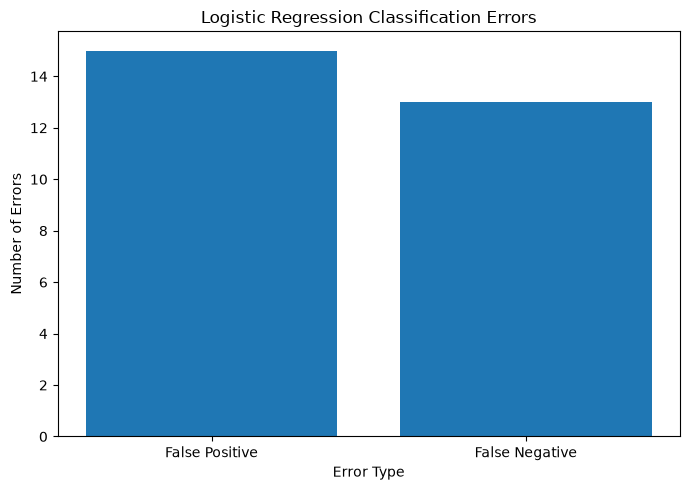

In [80]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    classification_error_counts["Error Type"],
    classification_error_counts["Count"]
)

ax.set_title("Logistic Regression Classification Errors")
ax.set_xlabel("Error Type")
ax.set_ylabel("Number of Errors")

fig.tight_layout()

chart_path = output_dir / "logistic_regression_classification_errors.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 14.5 Classification Error Pattern

The misclassified observations are examined relative to the 85-point
distinction threshold. Particular attention is given to whether false
positives and false negatives occur close to the threshold or whether the
errors appear concentrated in a particular class section or feature range.

The conclusion is based on the observed misclassified test observations rather
than assuming that a specific error pattern must exist.

In [81]:
threshold = 85

false_positive_count = len(false_positives)
false_negative_count = len(false_negatives)

false_positive_mean_score = false_positives["exam_score"].mean()
false_negative_mean_score = false_negatives["exam_score"].mean()

misclassified_within_five_points = misclassified_rows[
    (
        misclassified_rows["exam_score"] - threshold
    ).abs() <= 5
]

within_five_count = len(misclassified_within_five_points)
total_misclassified_count = len(misclassified_rows)

within_five_percentage = (
    within_five_count / total_misclassified_count * 100
)

classification_error_finding = f"""
### 14.5.1 Finding

Logistic Regression produced **{false_positive_count} false positives** and
**{false_negative_count} false negatives**, showing a relatively balanced
distribution between the two types of classification error.

The mean actual exam score among false positives was
**{false_positive_mean_score:.6f}**, while the mean actual exam score among
false negatives was **{false_negative_mean_score:.6f}**. This reflects the
direction of the errors: false positives are generally students below the
**{threshold}-point distinction threshold**, while false negatives are
generally students above it.

**{within_five_count} of {total_misclassified_count} misclassified observations
({within_five_percentage:.2f}%) were within five points of the threshold.**
This indicates that many classification errors occur near the decision
boundary, although the presence of errors farther from the threshold shows
that the model can also struggle with some less typical cases.
"""

display(Markdown(classification_error_finding))


### 14.5.1 Finding

Logistic Regression produced **15 false positives** and
**13 false negatives**, showing a relatively balanced
distribution between the two types of classification error.

The mean actual exam score among false positives was
**79.266667**, while the mean actual exam score among
false negatives was **89.300000**. This reflects the
direction of the errors: false positives are generally students below the
**85-point distinction threshold**, while false negatives are
generally students above it.

**17 of 28 misclassified observations
(60.71%) were within five points of the threshold.**
This indicates that many classification errors occur near the decision
boundary, although the presence of errors farther from the threshold shows
that the model can also struggle with some less typical cases.


### 14.5.2 Misclassified Scores Relative to the Distinction Threshold

The following visualization shows the actual exam scores of the
misclassified observations and marks the 85-point distinction threshold.

This helps determine whether classification errors are concentrated near the
boundary separating distinction from non-distinction.

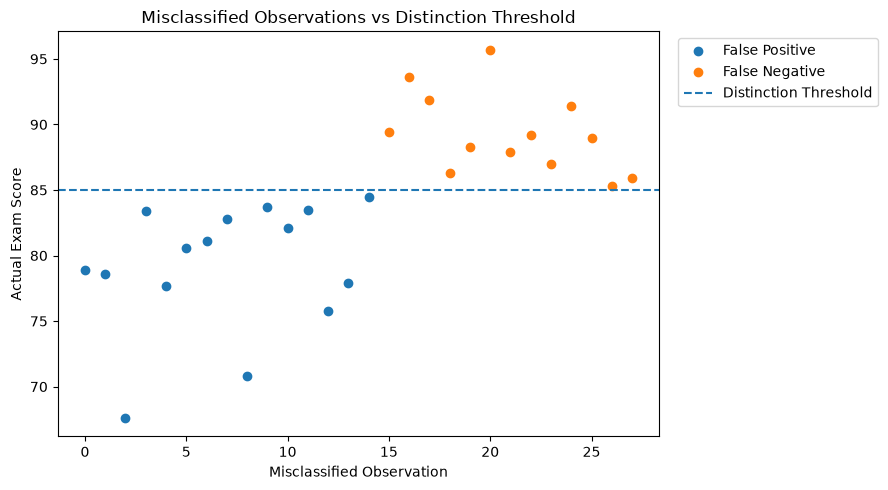

In [82]:
fig, ax = plt.subplots(figsize=(9, 5))

false_positive_scores = false_positives["exam_score"]

false_negative_scores = false_negatives["exam_score"]

ax.scatter(
    range(len(false_positive_scores)),
    false_positive_scores,
    label="False Positive"
)

ax.scatter(
    range(
        len(false_positive_scores),
        len(false_positive_scores) + len(false_negative_scores)
    ),
    false_negative_scores,
    label="False Negative"
)

ax.axhline(
    threshold,
    linestyle="--",
    label="Distinction Threshold"
)

ax.set_title("Misclassified Observations vs Distinction Threshold")

ax.set_xlabel("Misclassified Observation")

ax.set_ylabel("Actual Exam Score")

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

fig.tight_layout()

chart_path = output_dir / "logistic_regression_misclassified_scores.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 15. Calibration

Logistic Regression was selected as the final classification model based on
its strongest overall test-set performance across accuracy, precision, recall,
and F1.

The previous evaluation focused on the correctness of the final 0/1
predictions. Calibration examines a different property: whether the
probabilities produced by the classifier correspond to the observed frequency
of positive outcomes.

For example, if a model assigns approximately 70% probability to a group of
observations, a well-calibrated model should produce positive outcomes for
approximately 70% of those observations.

The calibration curve compares the model's average predicted probability with
the actual fraction of positive observations across probability bins. Points
close to the diagonal indicate reliable probability estimates, while larger
deviations indicate ranges where the model's confidence may not be trustworthy.

## 15.1 Generate Predicted Probabilities

Unlike `predict()`, which returns the final predicted class, `predict_proba()`
returns the estimated probability of each class.

For the binary `distinction` target, the second probability column represents
the model's estimated probability that an observation belongs to the positive
class, `distinction = 1`.

These probabilities are required for calibration analysis because calibration
evaluates the reliability of the model's confidence rather than only its final
classification decisions.

In [83]:
logistic_probabilities = logistic_model.predict_proba(
    X_test_class
)

logistic_positive_probabilities = logistic_probabilities[:, 1]
logistic_positive_probabilities

array([0.46676762, 0.74215489, 0.96464839, 0.74847901, 0.99297971,
       0.94179702, 0.93386052, 0.87176163, 0.89529198, 0.79578101,
       0.66374406, 0.16756663, 0.92022896, 0.20299598, 0.06666024,
       0.24788233, 0.64986829, 0.91722239, 0.96892057, 0.32704412,
       0.65842925, 0.38600211, 0.74904716, 0.79067927, 0.63778803,
       0.88370139, 0.96935499, 0.11473304, 0.28150835, 0.97765807,
       0.5645758 , 0.61042054, 0.88842157, 0.1183837 , 0.65730059,
       0.49265591, 0.69132611, 0.76561199, 0.45252328, 0.82403444,
       0.36957821, 0.13351882, 0.64934263, 0.62573076, 0.7599508 ,
       0.73620094, 0.39624943, 0.8711906 , 0.31355524, 0.84205296,
       0.47776357, 0.46543166, 0.96659577, 0.44554057, 0.98537503,
       0.99154815, 0.56120234, 0.49082279, 0.82299344, 0.51982477,
       0.84083323, 0.87167214, 0.76507188, 0.97935353, 0.96537125,
       0.33791643, 0.85135413, 0.96367444, 0.93140689, 0.58739148,
       0.26196727, 0.99069201, 0.73577349, 0.91869144, 0.81019

## 15.2 Calculate the Calibration Curve

The predicted probabilities are divided into probability bins using
`calibration_curve`.

For each bin, the average predicted probability is compared with the actual
fraction of positive observations. A perfectly calibrated model would have
these two quantities approximately equal within each bin.

In [84]:

calibration_fraction_of_positives, calibration_mean_predicted_value = (
    calibration_curve(
        y_test_class,
        logistic_positive_probabilities,
        n_bins=10,
        strategy="uniform"
    )
)

## 15.3 Calibration Summary

The calibration values are displayed numerically so that the distance between
predicted probability and observed positive frequency can be inspected for
each non-empty probability bin.

In [85]:
calibration_results = pd.DataFrame({
    "Mean Predicted Probability": calibration_mean_predicted_value,
    "Actual Fraction of Positives": calibration_fraction_of_positives
})

calibration_results["Calibration Gap"] = (
    calibration_results["Actual Fraction of Positives"]
    - calibration_results["Mean Predicted Probability"]
)

calibration_results["Absolute Calibration Gap"] = (
    calibration_results["Calibration Gap"].abs()
)

display(calibration_results)

,Mean Predicted Probability,Actual Fraction of Positives,Calibration Gap,Absolute Calibration Gap
0,0.060950,0.000000,-0.060950,0.060950
1,0.135621,0.111111,-0.024510,0.024510
2,0.256561,0.333333,0.076772,0.076772
3,0.355058,0.500000,0.144942,0.144942
4,0.461252,0.583333,0.122082,0.122082
5,0.549395,0.714286,0.164891,0.164891
6,0.644773,0.533333,-0.111439,0.111439
7,0.758627,0.785714,0.027087,0.027087
8,0.861211,0.882353,0.021141,0.021141
9,0.963686,0.962963,-0.000724,0.000724


## 15.4 Calibration Curve

The calibration curve compares the model's mean predicted probability with the
observed fraction of positive outcomes in each probability bin.

The diagonal reference line represents perfect calibration: a predicted
probability of 0.70, for example, would correspond to an observed positive
fraction of 0.70.

The closer the model's points are to this diagonal, the more trustworthy its
probability estimates are.

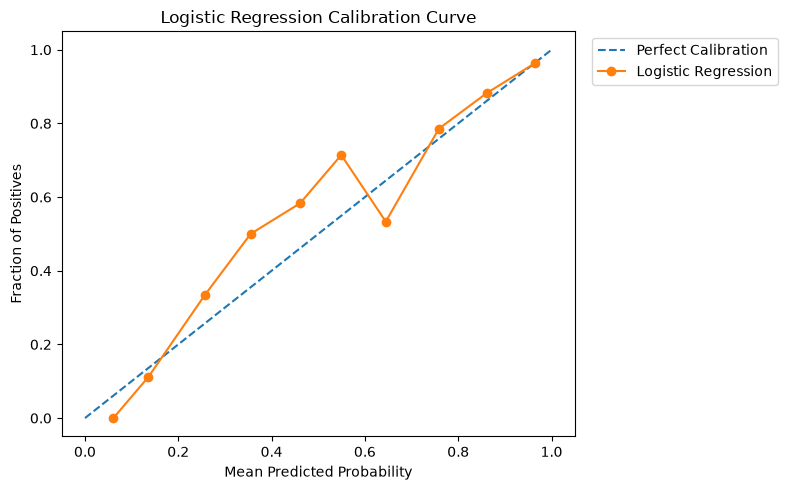

In [86]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

ax.plot(
    calibration_mean_predicted_value,
    calibration_fraction_of_positives,
    marker="o",
    label="Logistic Regression"
)

ax.set_title("Logistic Regression Calibration Curve")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

fig.tight_layout()

chart_path = output_dir / "logistic_regression_calibration_curve.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 15.5 Quantify Calibration Quality

The calibration gaps are quantified to support the visual interpretation.

The mean absolute calibration gap summarizes the average difference between
predicted probability and observed positive frequency across the non-empty
bins. The maximum absolute gap identifies the probability range where the
model deviates most strongly from perfect calibration.

In [87]:
mean_absolute_calibration_gap = (
    calibration_results["Absolute Calibration Gap"].mean()
)

maximum_calibration_gap = (
    calibration_results["Absolute Calibration Gap"].max()
)

weakest_calibration_index = (
    calibration_results["Absolute Calibration Gap"].idxmax()
)

weakest_calibration_predicted = (
    calibration_results.loc[
        weakest_calibration_index,
        "Mean Predicted Probability"
    ]
)

weakest_calibration_actual = (
    calibration_results.loc[
        weakest_calibration_index,
        "Actual Fraction of Positives"
    ]
)

## 15.6 Finding

The calibration finding summarizes how closely the model's predicted
probabilities correspond to the observed positive frequencies.

The conclusion is based on both the calibration curve and the measured
calibration gaps rather than assuming that a model with good classification
metrics must also be well calibrated.

In [88]:
calibration_finding = f"""

The Logistic Regression model has a mean absolute calibration gap of
**{mean_absolute_calibration_gap:.6f}** across the non-empty probability
bins, with a maximum absolute gap of **{maximum_calibration_gap:.6f}**.

The weakest calibration occurs around a mean predicted probability of
**{weakest_calibration_predicted:.6f}**, where the observed fraction of
positive outcomes is **{weakest_calibration_actual:.6f}**. The model is
therefore underconfident in this range because the observed positive fraction
is higher than the predicted probability.

Overall, the calibration appears **reasonably trustworthy but not perfect**:
the curve generally follows the diagonal, while the largest deviations occur
in the middle probability ranges. These bin-level estimates should be
interpreted with some caution because they are based on a finite test set.
"""

display(Markdown(calibration_finding))



The Logistic Regression model has a mean absolute calibration gap of
**0.075454** across the non-empty probability
bins, with a maximum absolute gap of **0.164891**.

The weakest calibration occurs around a mean predicted probability of
**0.549395**, where the observed fraction of
positive outcomes is **0.714286**. The model is
therefore underconfident in this range because the observed positive fraction
is higher than the predicted probability.

Overall, the calibration appears **reasonably trustworthy but not perfect**:
the curve generally follows the diagonal, while the largest deviations occur
in the middle probability ranges. These bin-level estimates should be
interpreted with some caution because they are based on a finite test set.


# 16. Reproducible Pipeline and Evaluation Report

The Wednesday and Thursday work is consolidated into a single reproducible
machine-learning pipeline using the same `students` dataset, engineered
features, fixed train/test splits, model definitions, evaluation metrics, and
error-analysis procedures.

The complete pipeline moves from simple baselines to Linear and Logistic
Regression, Decision Trees, and Random Forests. Model selection is based on
held-out test performance rather than algorithmic complexity.

The final evaluation also includes direct inspection of model errors and a
calibration analysis for the selected classifier. These additional checks
provide evidence beyond aggregate performance metrics and make the final model
choices defensible.

## 16.1 Reproducibility Check

The pipeline uses fixed seeds for every operation involving randomness.

The synthetic student dataset is generated with seed 21. The regression and
classification train/test splits use `random_state=42`, with stratification
applied to the classification split. The Logistic Regression, Decision Trees,
and Random Forest models also use fixed random states where applicable.

These controls ensure that restarting the notebook and running it from top to
bottom produces the same dataset, splits, model results, and evaluation
outputs.

In [89]:
reproducibility_summary = f"""

The dataset was generated with **seed=21**.

The regression train/test split uses **random_state=42** with a test size of
**{len(X_test) / len(X):.1%}**.

The classification split uses **random_state=42** with stratification to
preserve the class distribution between the training and test sets.

All tree and forest models use **random_state=42**, and Logistic Regression
uses **random_state=42** with a fixed maximum iteration limit.

The pipeline therefore uses fixed random settings throughout the modeling
workflow and is designed to produce reproducible results when executed from
the beginning of the notebook.
"""

display(Markdown(reproducibility_summary))



The dataset was generated with **seed=21**.

The regression train/test split uses **random_state=42** with a test size of
**20.0%**.

The classification split uses **random_state=42** with stratification to
preserve the class distribution between the training and test sets.

All tree and forest models use **random_state=42**, and Logistic Regression
uses **random_state=42** with a fixed maximum iteration limit.

The pipeline therefore uses fixed random settings throughout the modeling
workflow and is designed to produce reproducible results when executed from
the beginning of the notebook.


## 16.2 Complete Pipeline Summary

The final workflow follows a consistent modeling process:

1. Generate the reproducible `students` dataset.
2. Select predictive features and one-hot encode `class_section`.
3. Create the regression target and fixed regression train/test split.
4. Establish the mean-prediction regression baseline.
5. Train and evaluate Linear Regression.
6. Train and diagnose an unconstrained Decision Tree.
7. Constrain the Decision Tree using `max_depth=3`.
8. Train and evaluate the Random Forest Regressor.
9. Create the binary `distinction` classification target.
10. Create a fresh stratified classification train/test split.
11. Establish the majority-class classification baseline.
12. Train and evaluate Logistic Regression.
13. Train and evaluate the Decision Tree Classifier.
14. Train and evaluate the Random Forest Classifier.
15. Compare all models using consistent held-out test metrics.
16. Select the strongest regression and classification models.
17. Inspect the largest regression errors and classification mistakes.
18. Evaluate the calibration of the selected classifier.
19. Report the final evidence and model choices.

## 16.3 Final Model Summary

The final model choices are based on the comparison performed in Section 13,
with the error analysis and calibration results providing additional evidence
about their behavior.

In [90]:
final_model_summary = f"""

The selected regression model is **{best_regression_model}**, with a test
RMSE of **{best_regression_rmse:.6f}** and a test R² of
**{best_regression_r2:.6f}**.

The selected classification model is **{best_classification_model}**, with
an accuracy of **{best_classification_accuracy:.6f}**, precision of
**{best_classification_precision:.6f}**, recall of
**{best_classification_recall:.6f}**, and F1 of
**{best_classification_f1:.6f}**.

The results demonstrate that the more complex tree-based models did not
automatically outperform the simpler Linear and Logistic Regression models
on this dataset.
"""

display(Markdown(final_model_summary))



The selected regression model is **Linear Regression**, with a test
RMSE of **7.058469** and a test R² of
**0.525687**.

The selected classification model is **Logistic Regression**, with
an accuracy of **0.766667**, precision of
**0.812500**, recall of
**0.833333**, and F1 of
**0.822785**.

The results demonstrate that the more complex tree-based models did not
automatically outperform the simpler Linear and Logistic Regression models
on this dataset.


## 16.4 Final Pipeline Verification

The following checks verify that the key datasets, splits, models, evaluation
results, and analysis outputs required by the final pipeline have been created.

This provides a final structural check before the notebook is executed from
a fresh kernel.

In [91]:
required_pipeline_objects = [
    X,
    X_train,
    X_test,
    y_train,
    y_test,
    linear_model,
    tree_regressor,
    tree_depth3,
    random_forest_regressor,
    X_train_class,
    X_test_class,
    y_train_class,
    y_test_class,
    logistic_model,
    tree_classifier,
    random_forest_classifier,
    regression_comparison,
    classification_comparison,
    worst_regression_errors,
    misclassified_rows,
    calibration_results
]

pipeline_objects_available = all(
    obj is not None
    for obj in required_pipeline_objects
)

pipeline_verification_finding = f"""

The final pipeline verification confirms that all **{len(required_pipeline_objects)}**
required pipeline objects are available in the current notebook state.

Pipeline object verification status: **{pipeline_objects_available}**.


"""

display(Markdown(pipeline_verification_finding))



The final pipeline verification confirms that all **21**
required pipeline objects are available in the current notebook state.

Pipeline object verification status: **True**.




In [92]:
evaluation_report = f"""
## 16.5 Standalone Evaluation Report

### Task

The objective was to build and evaluate a reproducible machine-learning
pipeline for predicting student exam scores and classifying students into
distinction and non-distinction categories.

### Regression Evaluation

The regression baseline achieved an RMSE of **{baseline_rmse:.6f}** and an
R² of **{baseline_r2:.6f}**.

Linear Regression achieved an RMSE of **{linear_rmse:.6f}** and an R² of
**{linear_r2:.6f}**.

The unconstrained Decision Tree achieved an RMSE of **{tree_test_rmse:.6f}**
and an R² of **{tree_test_r2:.6f}**, while the depth-3 tree achieved an RMSE
of **{tree_depth3_test_rmse:.6f}** and an R² of **{tree_depth3_test_r2:.6f}**.

The Random Forest achieved an RMSE of **{forest_regression_rmse:.6f}** and
an R² of **{forest_regression_r2:.6f}**.

The selected regression model is **{best_regression_model}** because it
achieved the strongest held-out test performance.

### Classification Evaluation

The majority baseline achieved accuracy of **{baseline_accuracy:.6f}**,
precision of **{baseline_precision:.6f}**, recall of **{baseline_recall:.6f}**,
and F1 of **{baseline_f1:.6f}**.

Logistic Regression achieved accuracy of **{logistic_accuracy:.6f}**,
precision of **{logistic_precision:.6f}**, recall of
**{logistic_recall:.6f}**, and F1 of **{logistic_f1:.6f}**.

The Decision Tree achieved an F1 of **{tree_classifier_f1:.6f}**, while the
Random Forest achieved an F1 of **{forest_f1:.6f}**.

The selected classification model is **{best_classification_model}** because
it achieved the strongest overall precision-recall balance and the highest
performance across the reported classification metrics.

### Error Analysis

The regression analysis examined the five largest absolute residuals.
The classification analysis identified **{false_positive_count} false
positives** and **{false_negative_count} false negatives**.

Many classification errors occurred near the **85-point distinction
threshold**, while the largest regression errors included substantial
underprediction of unusually high scores and overprediction of some lower
scores.

### Calibration

The Logistic Regression model had a mean absolute calibration gap of
**{mean_absolute_calibration_gap:.6f}** and a maximum gap of
**{maximum_calibration_gap:.6f}**.

The weakest calibration occurred around a predicted probability of
**{weakest_calibration_predicted:.6f}**, where the observed positive fraction
was **{weakest_calibration_actual:.6f}**.

Overall, the calibration was reasonably trustworthy but not perfect, with the
largest deviations occurring in the middle probability ranges.

### Final Conclusion

The final model choices are based on held-out evidence rather than model
complexity. **{best_regression_model}** was selected for regression and
**{best_classification_model}** for classification.

The combination of model comparison, direct error analysis, and calibration
provides a more defensible evaluation than relying on a single performance
metric.
"""

display(Markdown(evaluation_report))


## 16.5 Standalone Evaluation Report

### Task

The objective was to build and evaluate a reproducible machine-learning
pipeline for predicting student exam scores and classifying students into
distinction and non-distinction categories.

### Regression Evaluation

The regression baseline achieved an RMSE of **10.297789** and an
R² of **-0.009560**.

Linear Regression achieved an RMSE of **7.058469** and an R² of
**0.525687**.

The unconstrained Decision Tree achieved an RMSE of **9.535998**
and an R² of **0.134282**, while the depth-3 tree achieved an RMSE
of **7.103141** and an R² of **0.519664**.

The Random Forest achieved an RMSE of **7.354371** and
an R² of **0.485085**.

The selected regression model is **Linear Regression** because it
achieved the strongest held-out test performance.

### Classification Evaluation

The majority baseline achieved accuracy of **0.650000**,
precision of **0.650000**, recall of **1.000000**,
and F1 of **0.787879**.

Logistic Regression achieved accuracy of **0.766667**,
precision of **0.812500**, recall of
**0.833333**, and F1 of **0.822785**.

The Decision Tree achieved an F1 of **0.771242**, while the
Random Forest achieved an F1 of **0.797468**.

The selected classification model is **Logistic Regression** because
it achieved the strongest overall precision-recall balance and the highest
performance across the reported classification metrics.

### Error Analysis

The regression analysis examined the five largest absolute residuals.
The classification analysis identified **15 false
positives** and **13 false negatives**.

Many classification errors occurred near the **85-point distinction
threshold**, while the largest regression errors included substantial
underprediction of unusually high scores and overprediction of some lower
scores.

### Calibration

The Logistic Regression model had a mean absolute calibration gap of
**0.075454** and a maximum gap of
**0.164891**.

The weakest calibration occurred around a predicted probability of
**0.549395**, where the observed positive fraction
was **0.714286**.

Overall, the calibration was reasonably trustworthy but not perfect, with the
largest deviations occurring in the middle probability ranges.

### Final Conclusion

The final model choices are based on held-out evidence rather than model
complexity. **Linear Regression** was selected for regression and
**Logistic Regression** for classification.

The combination of model comparison, direct error analysis, and calibration
provides a more defensible evaluation than relying on a single performance
metric.
